# 📊 Campaign Touch Analysis & Conversion Prediction
**Dataset:** CAMPAIGN_TOUCH.csv  
**Author:** Muhammad Laeeq Ur Rehman | github.com/data00077  
**Goal:** Analyze marketing campaign performance and predict customer conversion using Machine Learning

### Columns:
- `touch_id` — Unique ID for each campaign touch
- `customer_id` — Customer identifier
- `touch_date` — Date of campaign touch
- `channel` — Marketing channel (Email, SMS, Push, WhatsApp, Social Ads, Search Ads)
- `campaign_name` — Name of the campaign
- `outcome` — Result: Ignored / Clicked / Converted

## 📦 STEP 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 📂 STEP 2 — Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('campagin.csv')

print(f'📊 Dataset Shape: {df.shape}')
print(f'📋 Columns: {list(df.columns)}')
print()
df.head(10)

📊 Dataset Shape: (280103, 6)
📋 Columns: ['touch_id', 'customer_id', 'touch_date', 'channel', 'campaign_name', 'outcome']



,touch_id,customer_id,touch_date,channel,campaign_name,outcome
0,CT000000001,CUST000001,2023-05-08,Email,Health Bundle Offer,Ignored
1,CT000000002,CUST000001,2024-01-14,SMS,Weekend Deal,Ignored
2,CT000000003,CUST000001,2024-08-22,Push,Subscribe & Save,Ignored
3,CT000000004,CUST000001,2023-07-19,Email,Subscribe & Save,Ignored
4,CT000000005,CUST000001,2024-01-19,Push,New Launch Promo,Ignored
5,CT000000006,CUST000001,2025-10-27,Email,Seasonal Sale,Ignored
6,CT000000007,CUST000001,2024-11-25,Push,Subscribe & Save,Ignored
7,CT000000008,CUST000001,2024-11-23,WhatsApp,Cart Abandon Reminder,Ignored
8,CT000000009,CUST000001,2023-05-20,Email,Cart Abandon Reminder,Ignored
9,CT000000010,CUST000001,2023-05-18,Search Ads,Subscribe & Save,Ignored


## 🔍 STEP 3 — Exploratory Data Analysis (EDA)

In [3]:
# Basic info
print('=== Dataset Info ===')
print(df.info())
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Outcome Distribution ===')
print(df['outcome'].value_counts())
print()
print('=== Channels ===')
print(df['channel'].value_counts())
print()
print('=== Campaigns ===')
print(df['campaign_name'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280103 entries, 0 to 280102
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   touch_id       280103 non-null  object
 1   customer_id    280103 non-null  object
 2   touch_date     280103 non-null  object
 3   channel        280103 non-null  object
 4   campaign_name  280103 non-null  object
 5   outcome        280103 non-null  object
dtypes: object(6)
memory usage: 12.8+ MB
None

=== Missing Values ===
touch_id         0
customer_id      0
touch_date       0
channel          0
campaign_name    0
outcome          0
dtype: int64

=== Outcome Distribution ===
outcome
Ignored      252078
Converted     14089
Clicked       13936
Name: count, dtype: int64

=== Channels ===
channel
Email         78856
Push          61429
SMS           50186
Social Ads    42084
Search Ads    27970
WhatsApp      19578
Name: count, dtype: int64

=== Campaigns ===
campa

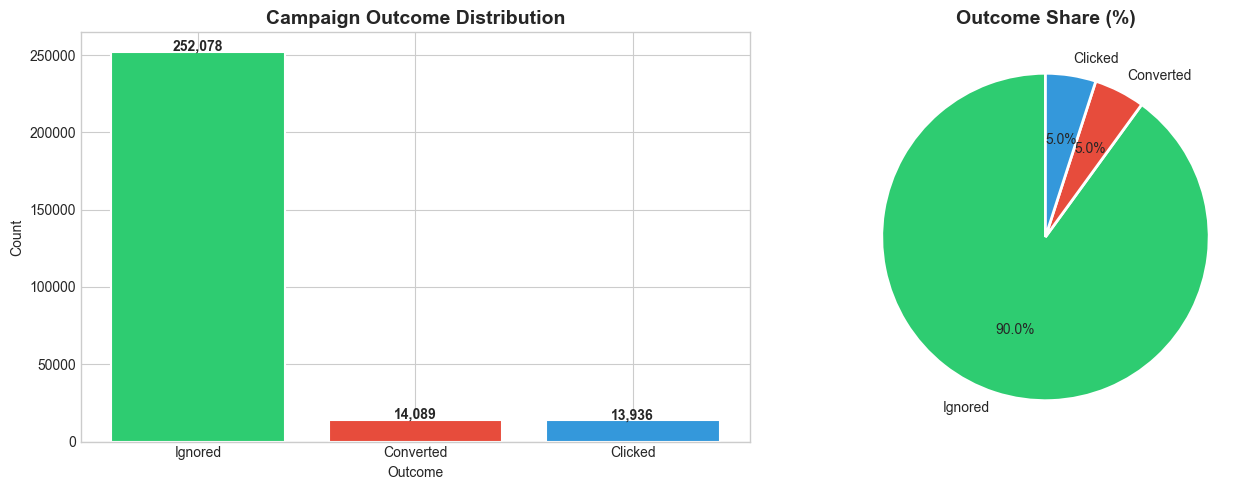

✅ Plot saved!


In [4]:
# ── PLOT 1: Outcome Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
outcome_counts = df['outcome'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[0].bar(outcome_counts.index, outcome_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Campaign Outcome Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')
for i, v in enumerate(outcome_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(outcome_counts.values, labels=outcome_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Outcome Share (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved!')

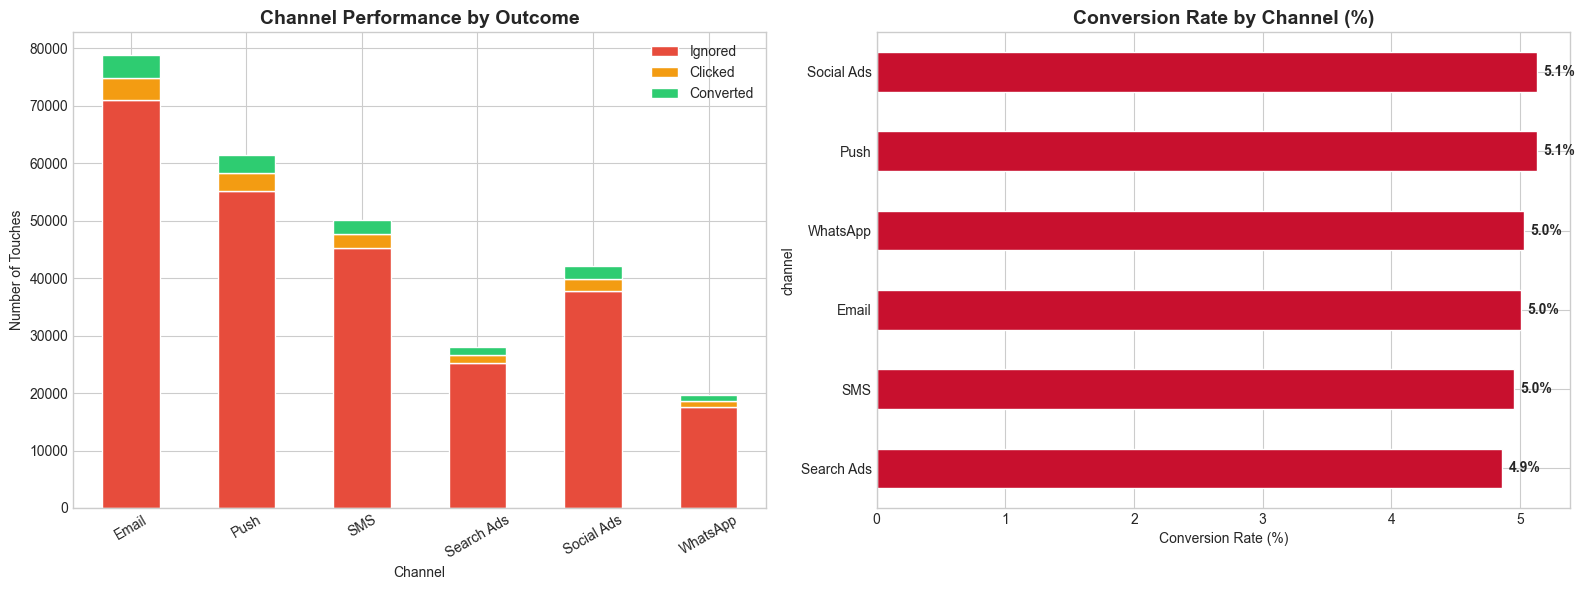

✅ Plot saved!


In [5]:
# ── PLOT 2: Channel Performance ──
channel_outcome = df.groupby(['channel', 'outcome']).size().unstack(fill_value=0)

# Conversion rate per channel
channel_outcome['conversion_rate'] = (
    channel_outcome.get('Converted', 0) / channel_outcome.sum(axis=1) * 100
).round(2)
channel_outcome['click_rate'] = (
    channel_outcome.get('Clicked', 0) / channel_outcome.sum(axis=1) * 100
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar
channel_outcome[['Ignored', 'Clicked', 'Converted']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white'
)
axes[0].set_title('Channel Performance by Outcome', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Number of Touches')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='upper right')

# Conversion rate bar
channel_outcome['conversion_rate'].sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='#C8102E', edgecolor='white'
)
axes[1].set_title('Conversion Rate by Channel (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Conversion Rate (%)')
for i, v in enumerate(channel_outcome['conversion_rate'].sort_values().values):
    axes[1].text(v + 0.05, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot2_channel_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved!')

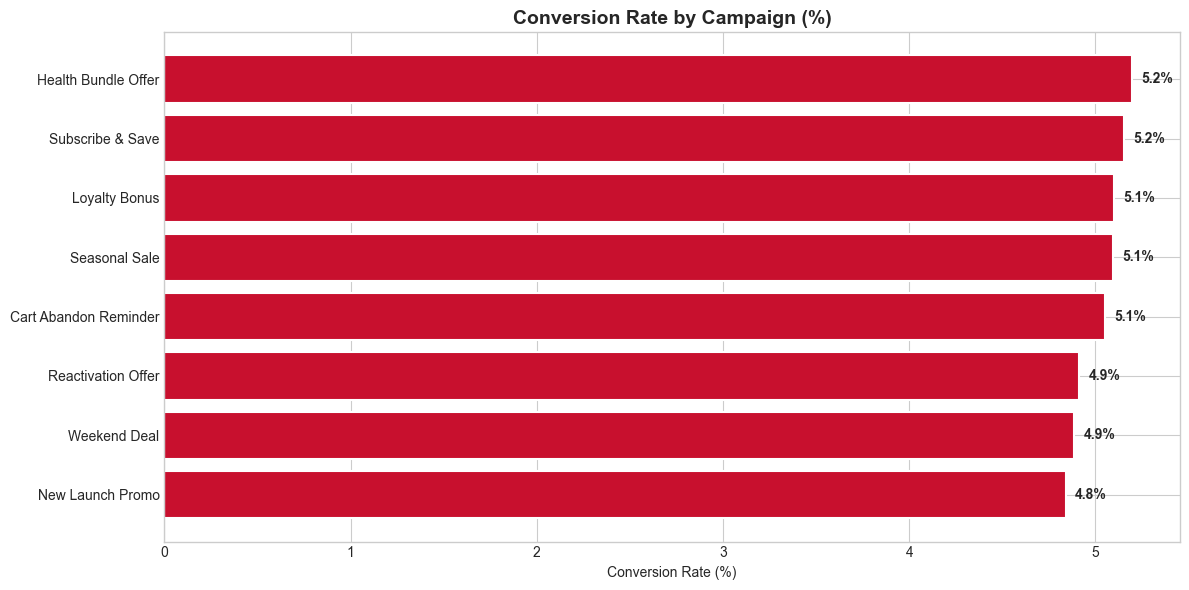

✅ Plot saved!


In [6]:
# ── PLOT 3: Campaign Performance ──
campaign_conv = df.groupby('campaign_name')['outcome'].apply(
    lambda x: (x == 'Converted').sum() / len(x) * 100
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(campaign_conv.index, campaign_conv.values,
               color='#C8102E', edgecolor='white', linewidth=1.5)
ax.set_title('Conversion Rate by Campaign (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Conversion Rate (%)')
for i, v in enumerate(campaign_conv.values):
    ax.text(v + 0.05, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot3_campaign_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved!')

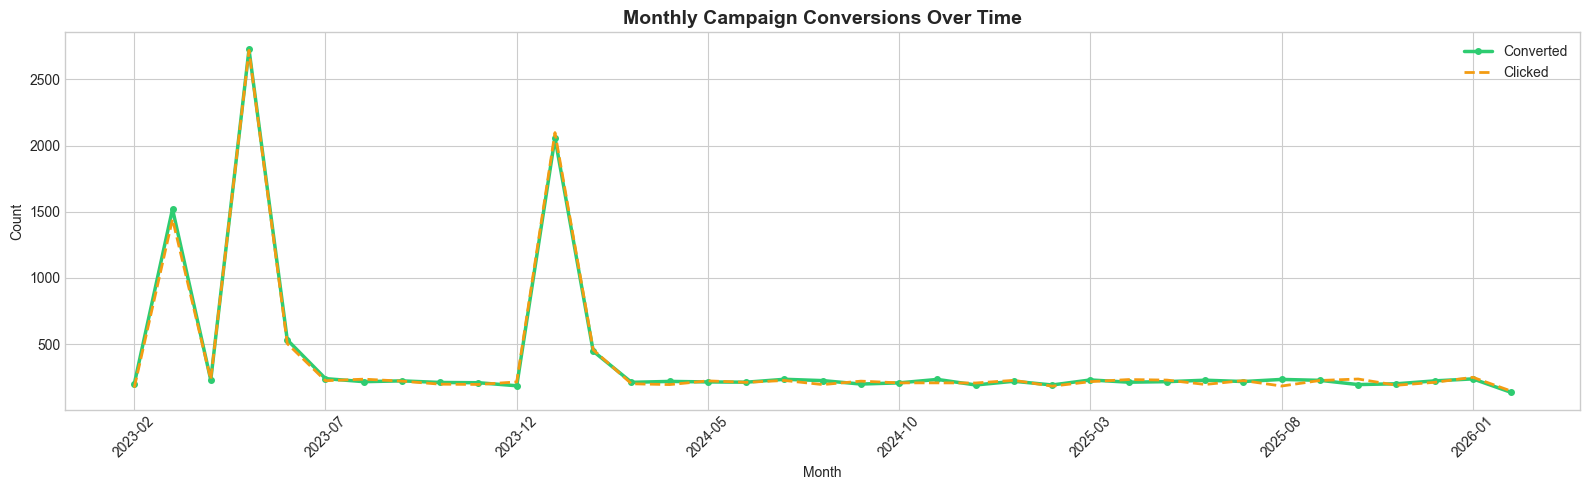

✅ Plot saved!


In [7]:
# ── PLOT 4: Monthly Trend ──
df['touch_date'] = pd.to_datetime(df['touch_date'])
df['year_month'] = df['touch_date'].dt.to_period('M')

monthly = df.groupby(['year_month', 'outcome']).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
monthly['Converted'].plot(ax=ax, color='#2ecc71', linewidth=2.5, marker='o', markersize=4, label='Converted')
monthly['Clicked'].plot(ax=ax, color='#f39c12', linewidth=2, linestyle='--', label='Clicked')

ax.set_title('Monthly Campaign Conversions Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot4_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved!')

## 🛠️ STEP 4 — Feature Engineering

In [8]:
# Create features from the dataset
df_model = df.copy()

# Date features
df_model['month'] = df_model['touch_date'].dt.month
df_model['day_of_week'] = df_model['touch_date'].dt.dayofweek  # 0=Monday, 6=Sunday
df_model['is_weekend'] = (df_model['day_of_week'] >= 5).astype(int)
df_model['quarter'] = df_model['touch_date'].dt.quarter

# Customer-level features: how many times was this customer touched?
customer_touch_count = df_model.groupby('customer_id')['touch_id'].count().reset_index()
customer_touch_count.columns = ['customer_id', 'total_touches']
df_model = df_model.merge(customer_touch_count, on='customer_id', how='left')

# Previous conversion rate per customer
customer_conv_rate = df_model.groupby('customer_id')['outcome'].apply(
    lambda x: (x == 'Converted').sum() / len(x)
).reset_index()
customer_conv_rate.columns = ['customer_id', 'customer_conv_rate']
df_model = df_model.merge(customer_conv_rate, on='customer_id', how='left')

print('✅ Feature engineering done!')
print(df_model[['channel', 'campaign_name', 'month', 'day_of_week', 
                'is_weekend', 'quarter', 'total_touches', 'customer_conv_rate', 'outcome']].head())

✅ Feature engineering done!
  channel        campaign_name  month  day_of_week  is_weekend  quarter  \
0   Email  Health Bundle Offer      5            0           0        2   
1     SMS         Weekend Deal      1            6           1        1   
2    Push     Subscribe & Save      8            3           0        3   
3   Email     Subscribe & Save      7            2           0        3   
4    Push     New Launch Promo      1            4           0        1   

   total_touches  customer_conv_rate  outcome  
0             28                 0.0  Ignored  
1             28                 0.0  Ignored  
2             28                 0.0  Ignored  
3             28                 0.0  Ignored  
4             28                 0.0  Ignored  


## 🤖 STEP 5 — Build ML Model (Conversion Prediction)

In [9]:
# Encode categorical columns
le_channel = LabelEncoder()
le_campaign = LabelEncoder()

df_model['channel_enc'] = le_channel.fit_transform(df_model['channel'])
df_model['campaign_enc'] = le_campaign.fit_transform(df_model['campaign_name'])

# Target: binary — Converted (1) vs Not Converted (0)
df_model['target'] = (df_model['outcome'] == 'Converted').astype(int)

# Features
features = ['channel_enc', 'campaign_enc', 'month', 'day_of_week',
            'is_weekend', 'quarter', 'total_touches', 'customer_conv_rate']

X = df_model[features]
y = df_model['target']

print(f'✅ Features: {features}')
print(f'📊 Target distribution: {y.value_counts().to_dict()}')
print(f'📈 Conversion rate: {y.mean()*100:.2f}%')

✅ Features: ['channel_enc', 'campaign_enc', 'month', 'day_of_week', 'is_weekend', 'quarter', 'total_touches', 'customer_conv_rate']
📊 Target distribution: {0: 266014, 1: 14089}
📈 Conversion rate: 5.03%


In [10]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'🔵 Training samples: {len(X_train):,}')
print(f'🔴 Testing samples:  {len(X_test):,}')

🔵 Training samples: 224,082
🔴 Testing samples:  56,021


In [11]:
# Train Random Forest Model
print('🚀 Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print()
print(f'✅ Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print()
print('📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Converted', 'Converted']))

🚀 Training Random Forest...

✅ Accuracy: 94.97%

📋 Classification Report:
               precision    recall  f1-score   support

Not Converted       0.95      1.00      0.97     53203
    Converted       0.00      0.00      0.00      2818

     accuracy                           0.95     56021
    macro avg       0.47      0.50      0.49     56021
 weighted avg       0.90      0.95      0.93     56021



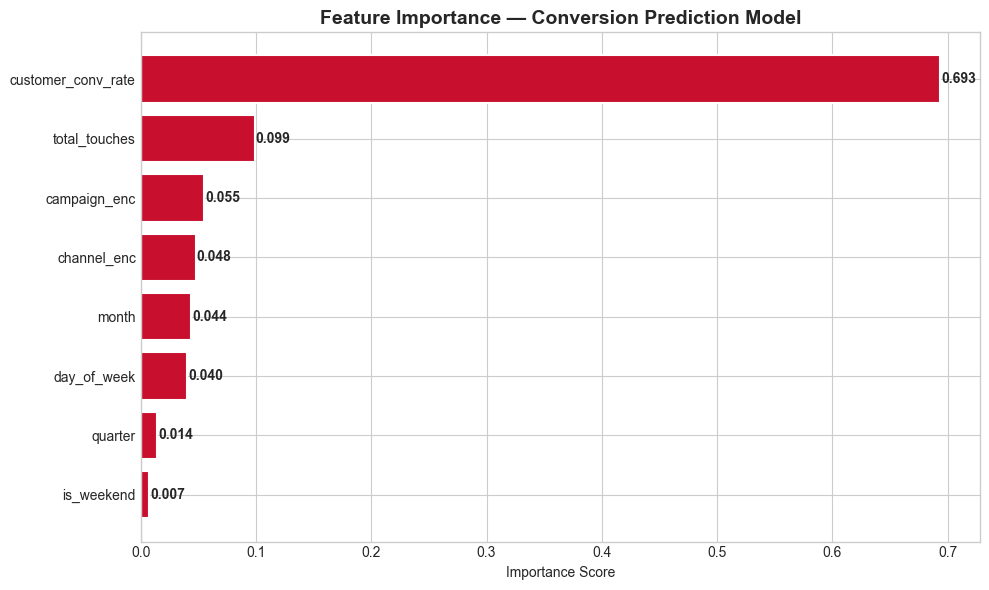

✅ Plot saved!


In [12]:
# ── PLOT 5: Feature Importance ──
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_imp.index, feat_imp.values, color='#C8102E', edgecolor='white', linewidth=1.5)
ax.set_title('Feature Importance — Conversion Prediction Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved!')

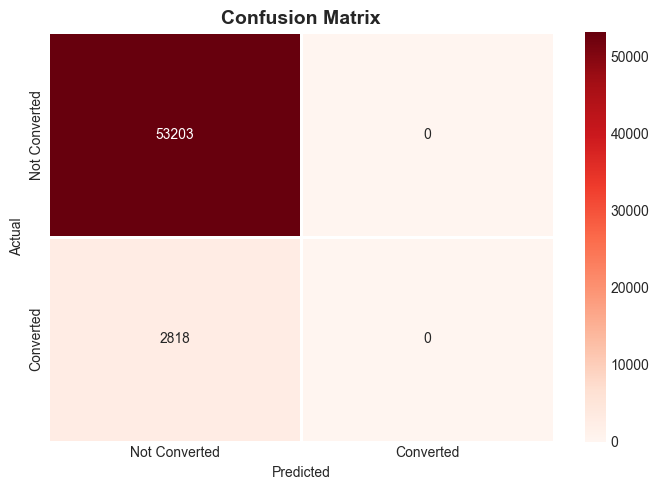

✅ Plot saved!


In [13]:
# ── PLOT 6: Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'],
            linewidths=2, ax=ax)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('plot6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved!')

## 💡 STEP 6 — Business Insights

In [14]:
print('=' * 55)
print('📊 KEY BUSINESS INSIGHTS — CAMPAIGN TOUCH ANALYSIS')
print('=' * 55)

# Best channel
best_channel = channel_outcome['conversion_rate'].idxmax()
best_rate = channel_outcome['conversion_rate'].max()
print(f'\n🏆 Best Performing Channel: {best_channel} ({best_rate:.1f}% conversion)')

# Best campaign
best_campaign = campaign_conv.idxmax()
best_camp_rate = campaign_conv.max()
print(f'🎯 Best Performing Campaign: {best_campaign} ({best_camp_rate:.1f}% conversion)')

# Weekend vs weekday
weekend_conv = df_model[df_model['is_weekend'] == 1]['target'].mean() * 100
weekday_conv = df_model[df_model['is_weekend'] == 0]['target'].mean() * 100
print(f'\n📅 Weekend Conversion Rate: {weekend_conv:.2f}%')
print(f'📅 Weekday Conversion Rate: {weekday_conv:.2f}%')

# Overall stats
total = len(df)
converted = (df['outcome'] == 'Converted').sum()
clicked = (df['outcome'] == 'Clicked').sum()
print(f'\n📈 Overall Stats:')
print(f'   Total Touches:   {total:,}')
print(f'   Conversions:     {converted:,} ({converted/total*100:.1f}%)')
print(f'   Clicks:          {clicked:,} ({clicked/total*100:.1f}%)')
print(f'   Ignored:         {total-converted-clicked:,} ({(total-converted-clicked)/total*100:.1f}%)')
print(f'\n🤖 Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print('=' * 55)

📊 KEY BUSINESS INSIGHTS — CAMPAIGN TOUCH ANALYSIS

🏆 Best Performing Channel: Push (5.1% conversion)
🎯 Best Performing Campaign: Health Bundle Offer (5.2% conversion)

📅 Weekend Conversion Rate: 4.97%
📅 Weekday Conversion Rate: 5.05%

📈 Overall Stats:
   Total Touches:   280,103
   Conversions:     14,089 (5.0%)
   Clicks:          13,936 (5.0%)
   Ignored:         252,078 (90.0%)

🤖 Model Accuracy: 94.97%


## ✅ Summary

This project demonstrates:
1. **EDA** on 280,000 marketing campaign touches
2. **Channel & Campaign analysis** to find best performers  
3. **Feature Engineering** — date features, customer-level aggregations
4. **ML Model** — Random Forest to predict customer conversion
5. **Business Insights** — actionable recommendations for campaign optimization

**Relevance to FMCG (Nestlé):** This type of analysis is used to optimize marketing spend across channels, identify best-performing campaigns, and predict which customers are most likely to convert — directly applicable to Nestlé's consumer marketing strategy.